In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF
from sklearn.metrics import precision_score, f1_score,recall_score,accuracy_score
!pip install torchsummary
from torchsummary import summary
from torch.optim.lr_scheduler import StepLR

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset,random_split,DataLoader,Subset

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
!mkdir output

# Custom Dataset preparation

In [3]:
class SlumDataset(Dataset):
  def __init__(self,image_dir,mask_dir,transform = None):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.images = os.listdir(image_dir)
    self.masks = os.listdir(mask_dir)

  def __len__(self):
    return len(self.masks)

  def __getitem__(self,index):
    img_path = os.path.join(self.image_dir,self.images[index])
    mask_path = os.path.join(self.mask_dir,self.masks[index])

    image = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path), dtype = np.float32)
    mask = (mask//246.0)
    image = (image/255.0)


    if self.transform != None:
      augment = self.transform(image = image,mask = mask)
      image = augment['image']
      mask = augment['mask']

      if(image.shape[1:] != mask.shape):
        print("-------------- ---------------------------")
        print("!!!Warning!!!")
        print(image.shape[1:])
        print(mask.shape)

    return image,mask

In [4]:
def save_checkpoint(state,filename = "my_checkpoint.pth.tar"):
  print("=> Saving checkpoint")
  torch.save(state,filename)

def load_checkpoint(checkpoint,model,optimizer):
  print("=> Loading checkpoint")
  model.load_state_dict(checkpoint["state_dict"])
  optimizer.load_state_dict(checkpoint["optimizer"])

# Get the training and validation Dataloaders

In [5]:
def get_loaders(
    train_dir,
    train_mask_dir,
    val_dir,
    val_mask_dir,
    batch_size,
    train_transform,
    val_transform,
    train_val,
    num_workers = 2,
    pin_memory = True,
):

  train_ds = SlumDataset(
      image_dir = train_dir,
      mask_dir = train_mask_dir,
      transform = train_transform
  )

  train_loader = DataLoader(
      train_ds,
      batch_size = batch_size,
      num_workers = num_workers,
      pin_memory = pin_memory,
      shuffle = True,
  )

  val_ds = SlumDataset(
      image_dir = val_dir,
      mask_dir = val_mask_dir,
      transform = val_transform
  )

  val_loader = DataLoader(
      val_ds,
      batch_size = batch_size,
      num_workers = num_workers,
      pin_memory = pin_memory,
      shuffle = False,
  )

  return train_loader, val_loader

# Saved the predicted images along with the original image

In [6]:
def save_predictions_as_imgs(loader,model,folder="saved_images/",device = "cuda"):
  model.eval()
  for idx, (x,y) in enumerate(loader):
    x = x.to(device = device)
    y = y.unsqueeze(1).to(device)

    with torch.no_grad():
      preds = torch.sigmoid(model(x))
      preds = (preds > 0.5).float()

    torchvision.utils.save_image(preds,f"{folder}/pred_{idx}.jpg")
    torchvision.utils.save_image(y,f"{folder}/{idx}.jpg")

  model.train()

# Unet Model with resnet50 used as encoder which is trained on imagenet Dataset

In [7]:
class ConvBlock(nn.Module):
  def __init__(self,in_channels,out_channels,padding=1,kernel_size = 3,stride = 1,with_nonlinearity=True):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, out_channels, padding=padding, kernel_size=kernel_size, stride=stride)
    self.bn = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()
    self.with_nonlinearity = with_nonlinearity

  def forward(self,x):
    x = self.conv(x)
    x = self.bn(x)
    if self.with_nonlinearity:
        x = self.relu(x)

    return x

In [8]:
class Bridge(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.bridge = nn.Sequential(
        ConvBlock(in_channels, out_channels),
        ConvBlock(out_channels, out_channels)
    )

  def forward(self, x):
    x = self.bridge(x)
    return x

In [9]:
class UpBlockForUNetWithResNet50(nn.Module):
  """
    Up block that encapsulates one up-sampling step which consists of Upsample -> ConvBlock -> ConvBlock
  """

  def __init__(self, in_channels, out_channels, up_conv_in_channels=None, up_conv_out_channels=None,upsampling_method="conv_transpose"):
    super().__init__()
    if up_conv_in_channels == None:
        up_conv_in_channels = in_channels

    if up_conv_out_channels == None:
        up_conv_out_channels = out_channels

    if upsampling_method == "conv_transpose":
        self.upsample = nn.ConvTranspose2d(up_conv_in_channels, up_conv_out_channels, kernel_size=2, stride=2)

    self.conv_block_1 = ConvBlock(in_channels, out_channels)
    self.conv_block_2 = ConvBlock(out_channels, out_channels)

  def forward(self, up_x, down_x):
    """
      :param up_x: this is the output from the previous up block
      :param down_x: this is the output from the down block
      :return: upsampled feature map
    """

    x = self.upsample(up_x)

    if x.shape != down_x.shape:
      x = TF.resize(x,size = down_x.shape[2:],antialias=False)

    x = torch.cat([x, down_x], 1)
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    return x

In [10]:
class UNetWithResnet50Encoder(nn.Module):
  DEPTH = 6

  def __init__(self, n_classes=1):
    super().__init__()
    resnet = torchvision.models.resnet.resnet50(pretrained=True)
    for param in resnet.parameters():
      param.requires_grad = False

    down_blocks = []
    up_blocks = []

    self.input_block = nn.Sequential(*list(resnet.children()))[:3]
    self.input_pool = list(resnet.children())[3]

    for bottleneck in list(resnet.children()):
        if isinstance(bottleneck, nn.Sequential):
            down_blocks.append(bottleneck)

    self.down_blocks = nn.ModuleList(down_blocks)
    self.bridge = Bridge(2048, 2048)

    up_blocks.append(UpBlockForUNetWithResNet50(2048, 1024))
    up_blocks.append(UpBlockForUNetWithResNet50(1024, 512))
    up_blocks.append(UpBlockForUNetWithResNet50(512, 256))
    up_blocks.append(UpBlockForUNetWithResNet50(in_channels=128 + 64, out_channels=128,up_conv_in_channels=256, up_conv_out_channels=128))
    up_blocks.append(UpBlockForUNetWithResNet50(in_channels=64 + 3, out_channels=64,up_conv_in_channels=128, up_conv_out_channels=64))

    self.up_blocks = nn.ModuleList(up_blocks)
    self.out = nn.Conv2d(64, n_classes, kernel_size=1, stride=1)

  def forward(self, x, with_output_feature_map=False):
    pre_pools = dict()
    pre_pools[f"layer_0"] = x

    x = self.input_block(x)
    pre_pools[f"layer_1"] = x

    x = self.input_pool(x)

    for i, block in enumerate(self.down_blocks, 2):
        x = block(x)
        if i == (UNetWithResnet50Encoder.DEPTH - 1):
            continue
        pre_pools[f"layer_{i}"] = x

    x = self.bridge(x)

    for i, block in enumerate(self.up_blocks, 1):
        key = f"layer_{UNetWithResnet50Encoder.DEPTH - 1 - i}"
        x = block(x, pre_pools[key])

    output_feature_map = x

    x = self.out(x)
    del pre_pools

    if with_output_feature_map:
        return x, output_feature_map
    else:
        return x

# Implement Focal Loss using predefined BCEWithLogitsLoss

In [11]:
# Custom Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss()(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return focal_loss

# All the hyperparameters and dataset path

In [12]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from numpy import random

import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

# Hyperparameters
LEARNING_RATE = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 10
NUM_WORKERS = 2
train_val = 0.8
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
train_valid = 0.8

PIN_MEMORY = True
LOAD_MODEL = True

TRAIN_IMG_DIR = '/kaggle/input/slum-area-dataset/Data/train_img'
TRAIN_MASK_DIR = '/kaggle/input/slum-area-dataset/Data/train_mask'
val_dir = '/kaggle/input/slum-area-dataset/Data/val_img/val_img'
val_mask_dir = '/kaggle/input/slum-area-dataset/Data/val_mask/val_mask'
saved_folder = '/kaggle/working/output'

# Training function

In [13]:
def train_fn(loader,model,optimizer,loss_fn,scaler,losses):
  loop = tqdm(loader)

  for batch_idx, (data,targets) in enumerate(loop):
    data = data.to(device = device)
    targets = targets.float().unsqueeze(1).to(device = device)
    targ = targets

    # forward
    with torch.cuda.amp.autocast():
      predictions = torch.sigmoid(model(data))
      loss = loss_fn(predictions,targets)
        
    # backward
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # update tqdm loop
    loop.set_postfix(loss = loss.item())
    
    losses.append(loss.item())

In [14]:
train_transform = A.Compose(
    [
      A.Resize(height = IMAGE_HEIGHT,width = IMAGE_WIDTH),
      A.RandomCrop(height = IMAGE_HEIGHT,width=IMAGE_WIDTH),
      A.Rotate(limit = 35,p=1.0),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.1),
      A.Normalize(
          mean=[0.0,0.0,0.0],
          std = [1.0,1.0,1.0],
          max_pixel_value = 1.0
      ),
      ToTensorV2(),
    ], is_check_shapes=False
  )

val_transform = A.Compose(
    [
     A.Resize(height = IMAGE_HEIGHT,width = IMAGE_WIDTH),
     A.RandomCrop(height = IMAGE_HEIGHT,width=IMAGE_WIDTH),
     A.Normalize(
      mean=[0.0,0.0,0.0],
      std = [1.0,1.0,1.0],
      max_pixel_value = 1.0
    ),
    ToTensorV2(),
  ], is_check_shapes=False
  )
    
train_loader,val_loader = get_loaders(
      TRAIN_IMG_DIR,
      TRAIN_MASK_DIR,
      val_dir,
      val_mask_dir,
      BATCH_SIZE,
      train_transform,
      val_transform,
      train_val,
      NUM_WORKERS,
      PIN_MEMORY,
  )

model = UNetWithResnet50Encoder().to("cuda" if torch.cuda.is_available() else "cpu")

optimizers = {'Adadelta': optim.Adadelta(model.parameters(), lr = LEARNING_RATE),
             'Adagrad': optim.Adagrad(model.parameters(), lr = LEARNING_RATE),
             'SGD': optim.SGD(model.parameters(), lr = LEARNING_RATE), 
             'RMSPROP': optim.RMSprop(model.parameters(), lr = LEARNING_RATE), 
             'Adam': optim.Adam(model.parameters(), lr = LEARNING_RATE),
             
            }

loss_functions = {
    'Focal': FocalLoss(),
    'Hinge': nn.HingeEmbeddingLoss(),
    'BCE': nn.BCEWithLogitsLoss(),
    'MSE': nn.MSELoss(),
}

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 63.1MB/s]


100%|██████████| 178/178 [02:51<00:00,  1.04it/s, loss=0.255]


Adadelta is done


100%|██████████| 178/178 [02:53<00:00,  1.03it/s, loss=0.195]


Adagrad is done


100%|██████████| 178/178 [02:51<00:00,  1.04it/s, loss=0.146]


SGD is done


100%|██████████| 178/178 [02:53<00:00,  1.02it/s, loss=0.133]


RMSPROP is done


100%|██████████| 178/178 [02:55<00:00,  1.01it/s, loss=0.16]


Adam is done
Focal is done


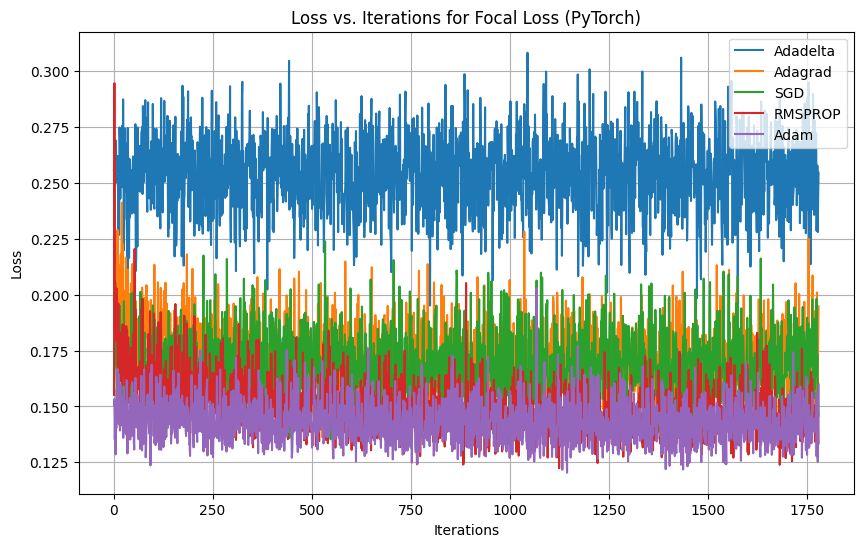

100%|██████████| 178/178 [02:57<00:00,  1.00it/s, loss=0.922]


Adadelta is done


100%|██████████| 178/178 [02:57<00:00,  1.01it/s, loss=0.89]


Adagrad is done


100%|██████████| 178/178 [02:58<00:00,  1.00s/it, loss=0.94]


SGD is done


100%|██████████| 178/178 [02:59<00:00,  1.01s/it, loss=0.711]


RMSPROP is done


100%|██████████| 178/178 [03:01<00:00,  1.02s/it, loss=0.726]


Adam is done
Hinge is done


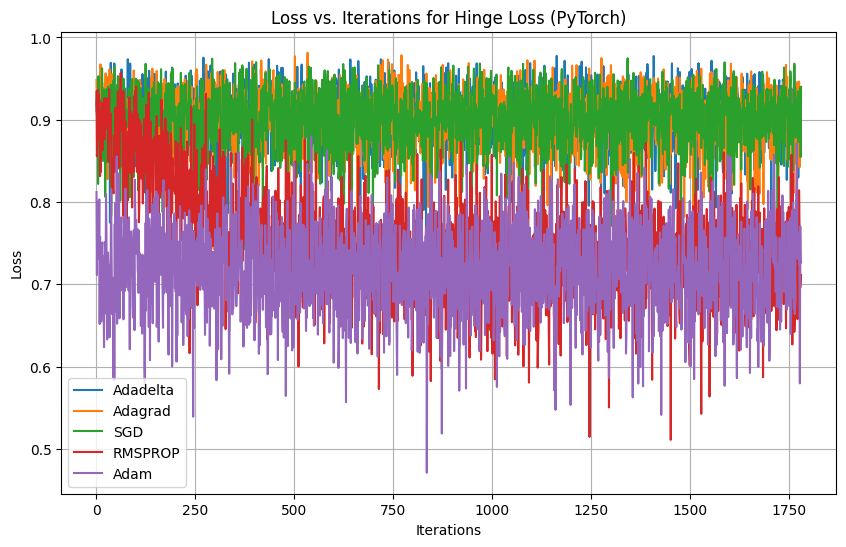

100%|██████████| 178/178 [02:56<00:00,  1.01it/s, loss=0.738]


Adadelta is done


100%|██████████| 178/178 [02:56<00:00,  1.01it/s, loss=0.729]


Adagrad is done


100%|██████████| 178/178 [02:57<00:00,  1.01it/s, loss=0.714]


SGD is done


100%|██████████| 178/178 [02:55<00:00,  1.01it/s, loss=0.732]


RMSPROP is done


100%|██████████| 178/178 [02:59<00:00,  1.01s/it, loss=0.724]


Adam is done
BCE is done


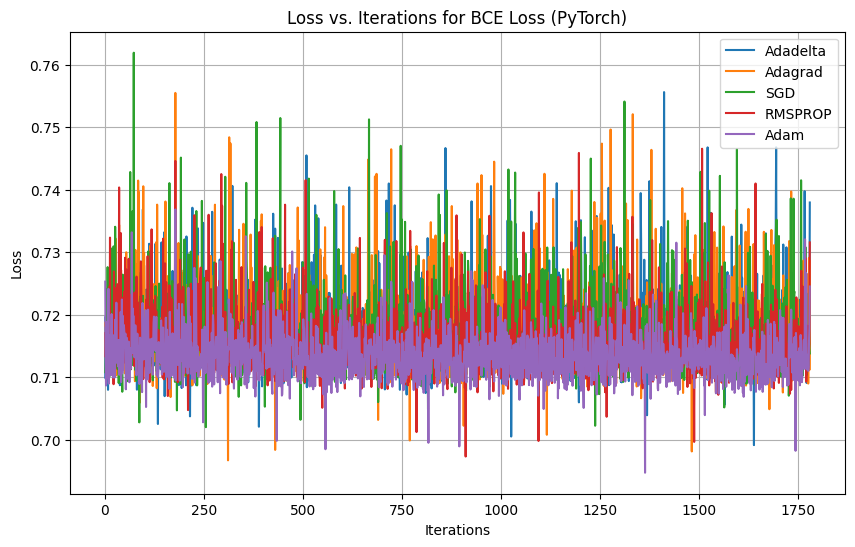

100%|██████████| 178/178 [02:58<00:00,  1.00s/it, loss=0.355]


Adadelta is done


100%|██████████| 178/178 [02:59<00:00,  1.01s/it, loss=0.217]


Adagrad is done


100%|██████████| 178/178 [02:56<00:00,  1.01it/s, loss=0.548]


SGD is done


100%|██████████| 178/178 [02:58<00:00,  1.00s/it, loss=0.277]


RMSPROP is done


100%|██████████| 178/178 [03:01<00:00,  1.02s/it, loss=0.449]


Adam is done
MSE is done


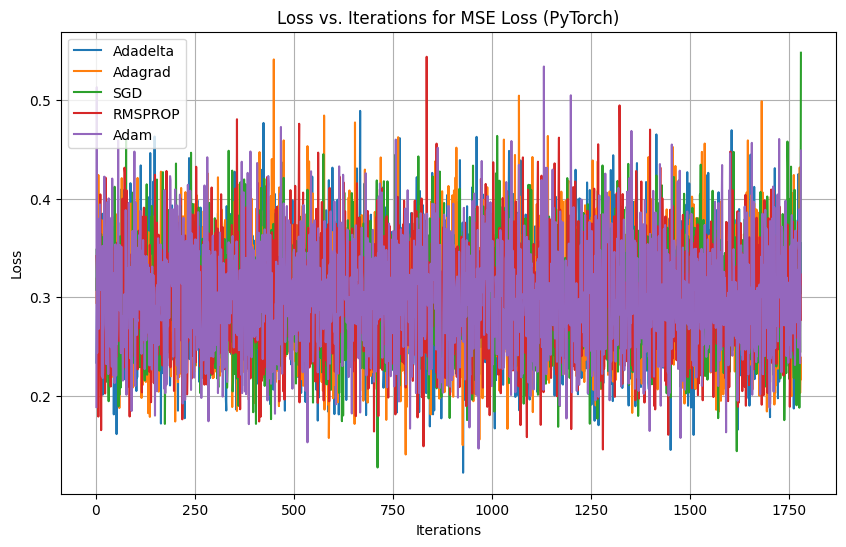

In [15]:
results = {}
for loss_name , loss_function in loss_functions.items():
    plt.figure(figsize=(10, 6))
    loss_history = {}
    for optimizer_name,optimizer in optimizers.items():
        model = model
        optimizer = optimizer
        scheduler = StepLR(optimizer, step_size=4, gamma=0.1)
        scaler = torch.cuda.amp.GradScaler()
        losses = []
        for epoch in range(NUM_EPOCHS):
            train_fn(train_loader,model,optimizer,loss_function,scaler,losses)
            scheduler.step()
        
        loss_history[optimizer_name] = losses
        print(f"{optimizer_name} is done")
        plt.plot(range(1, len(losses)+1), losses, label=optimizer_name)
    print(f"{loss_name} is done")
    results[loss_name] = loss_history
    plt.title(f'Loss vs. Iterations for {loss_name} Loss (PyTorch)')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
# Plot the losses
# plt.figure(figsize=(12, 8))
# for loss_name, loss_history in results.items():
#     for optimizer_name, loss_values in loss_history.items():
#         label = f'{loss_name} + {optimizer_name}'
#         plt.plot(range(1, NUM_EPOCHS+1), loss_values, label=label)

# plt.title('Loss vs. Epochs for Different Loss Functions and Optimizers (PyTorch)')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)
# plt.show()